In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path(r"C:\Users\ACER\Desktop\upi transaction 2016-26.xlsx")

In [3]:
#load and clean data

In [2]:
df = pd.read_excel(DATA_DIR)
df["ds"] = pd.to_datetime(df["Month"], format="%B-%Y")
df.isnull().sum()

Month                       0
No. of Banks live on UPI    0
Volume (In Mn.)             0
Value (In Cr.)              0
ds                          0
dtype: int64

In [3]:
# Clean the volume column: strip commas/whitespace and convert to numeric
# e.g. "14,223" -> 14223.0
df['Volume (In Mn.)'] = df['Volume (In Mn.)'].astype(str).str.replace(',', '').str.strip().astype(float)
df.head()

,Month,No. of Banks live on UPI,Volume (In Mn.),Value (In Cr.),ds
0,April-2026,713,22346.80,"29,029,88.05",2026-04-01
1,March-2026,705,22641.11,2952542.05,2026-03-01
2,February-2026,694,20394.18,2684229.29,2026-02-01
3,January-2026,691,21703.44,2833481.22,2026-01-01
4,December-2025,685,21634.67,2796712.73,2025-12-01


In [7]:
# exploaratoty analysis

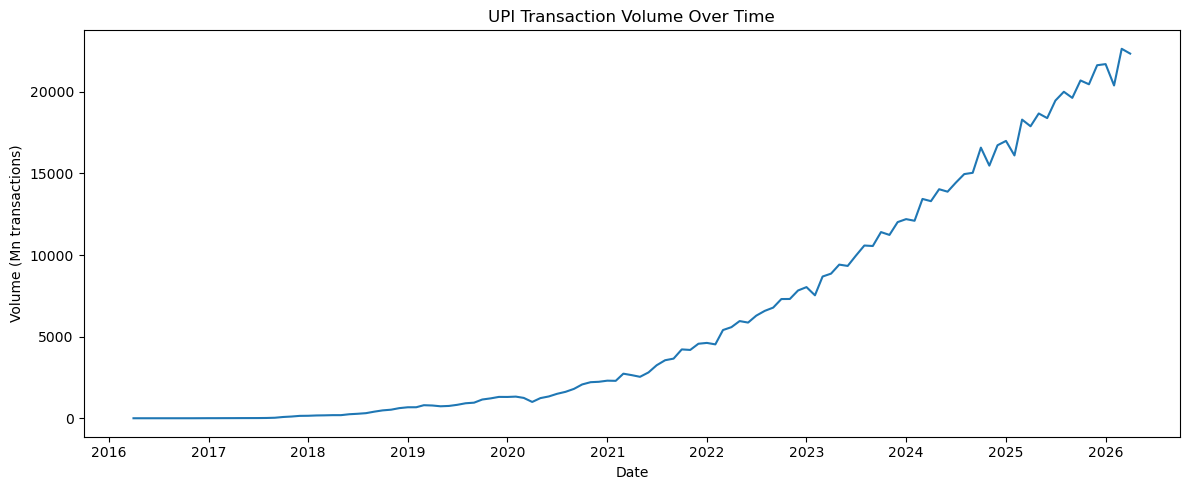

In [4]:
df_sorted = df.sort_values('ds').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(df_sorted['ds'], df_sorted['Volume (In Mn.)'])
plt.title("UPI Transaction Volume Over Time")
plt.xlabel('Date')
plt.ylabel("Volume (Mn transactions)")
plt.tight_layout()
plt.show()

In [9]:
# events

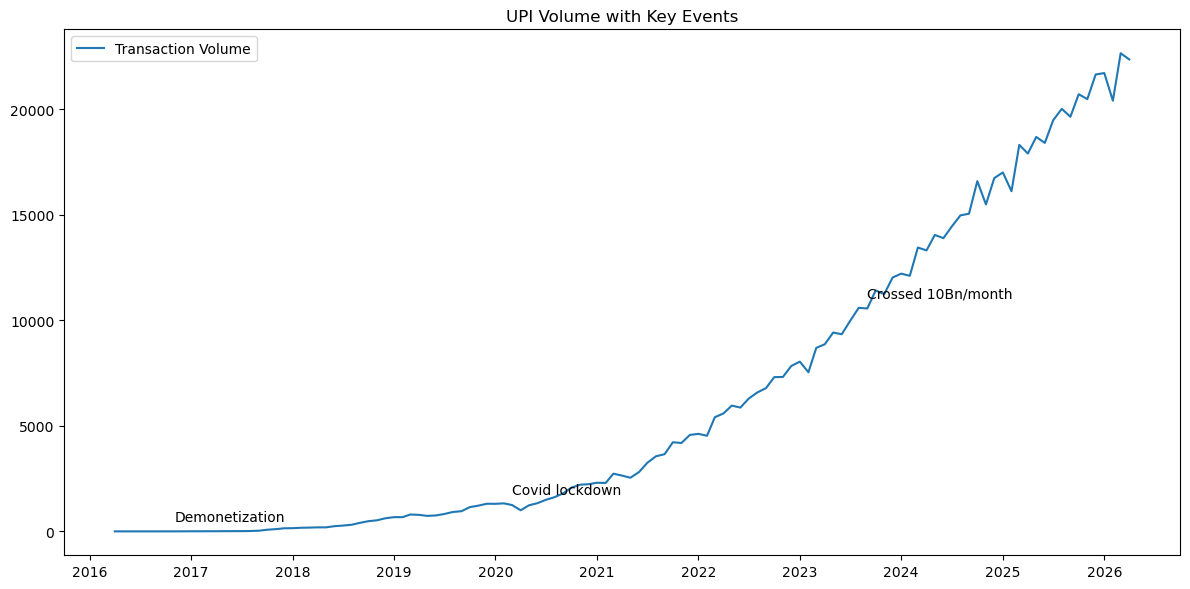

In [5]:
events = {'2016-11': 'Demonetization', '2020-03': 'Covid lockdown', '2023-09': 'Crossed 10Bn/month'}

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_sorted["ds"], df_sorted["Volume (In Mn.)"], label="Transaction Volume")

for date, label in events.items():
    x = pd.to_datetime(date)
    y = df_sorted.loc[df_sorted['ds'] == x, 'Volume (In Mn.)'].values
    if len(y):
        ax.annotate(label, xy=(x, y[0]), xytext=(x, y[0] + 500))

plt.title("UPI Volume with Key Events")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# month-over-month growth

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


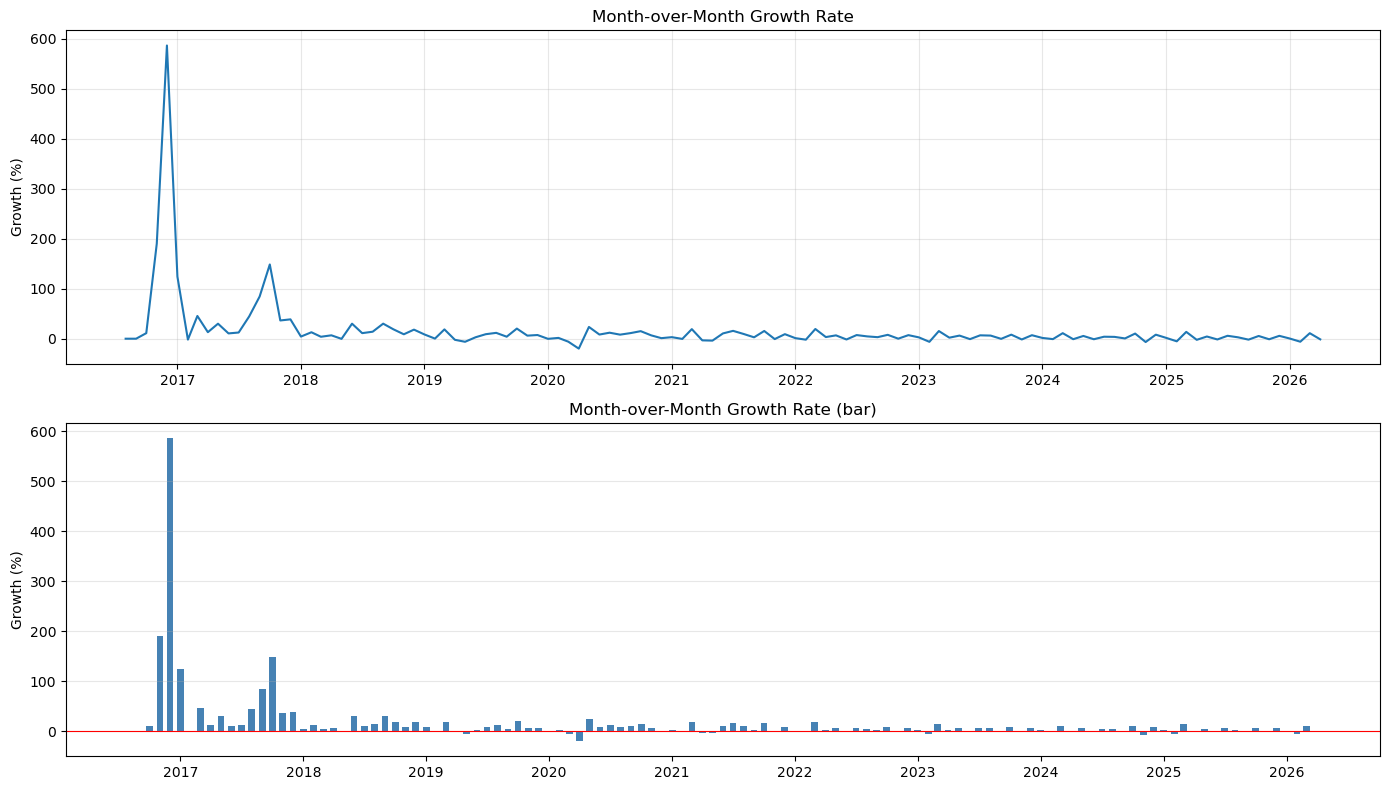

In [6]:
df_sorted["growth"] = df_sorted["Volume (In Mn.)"].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_sorted['ds'], df_sorted['growth'])
axes[0].set_title("Month-over-Month Growth Rate")
axes[0].set_ylabel("Growth (%)")
axes[0].grid(alpha=0.3)

axes[1].bar(df_sorted['ds'], df_sorted['growth'], color='steelblue', width=20)
axes[1].axhline(0, color='red', linewidth=0.8)
axes[1].set_title("Month-over-Month Growth Rate (bar)")
axes[1].set_ylabel("Growth (%)")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


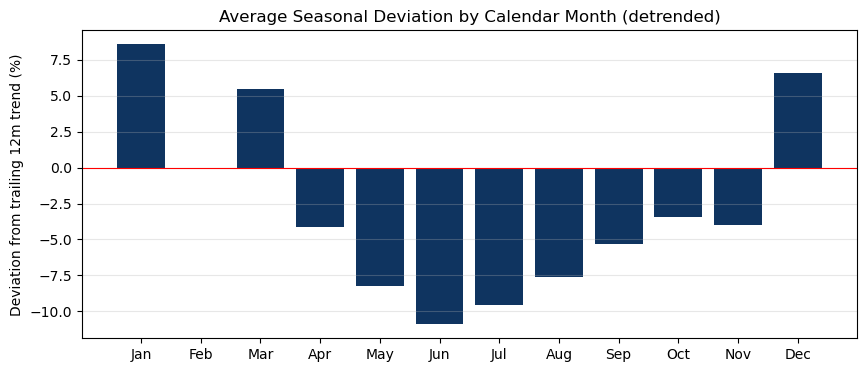

In [8]:
df_sorted["calendar_month"] = df_sorted["ds"].dt.month

# Detrend: express each month as % deviation from its own trailing 12-month average,
# so year-over-year growth doesn't leak into the seasonality signal
df_sorted["trend_12m"] = df_sorted["Volume (In Mn.)"].rolling(12, center=True).mean()
df_sorted["seasonal_pct"] = (df_sorted["Volume (In Mn.)"] / df_sorted["trend_12m"] - 1) * 100

monthly_avg = df_sorted.groupby("calendar_month")["seasonal_pct"].mean()

plt.figure(figsize=(10, 4))
plt.bar(monthly_avg.index, monthly_avg.values, color="#0f3460")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.axhline(0, color="red", linewidth=0.8)
plt.title("Average Seasonal Deviation by Calendar Month (detrended)")
plt.ylabel("Deviation from trailing 12m trend (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [12]:
#seasonality check

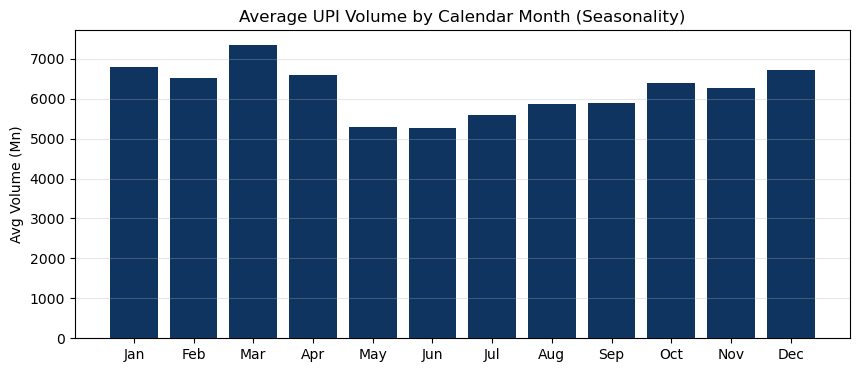

In [9]:
df_sorted["calendar_month"] = df_sorted["ds"].dt.month
monthly_avg = df_sorted.groupby("calendar_month")["Volume (In Mn.)"].mean()

plt.figure(figsize=(10, 4))
plt.bar(monthly_avg.index, monthly_avg.values, color="#0f3460")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.title("Average UPI Volume by Calendar Month (Seasonality)")
plt.ylabel("Avg Volume (Mn)")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_sorted["Volume (In Mn.)"].dropna())
print("ADF Statistic :", round(result[0], 4))
print("p-value       :", round(result[1], 4))
print("Critical (5%) :", round(result[4]["5%"], 4))

if result[1] > 0.05:
    print("-> Series is NON-STATIONARY (has trend) - consistent with UPI's strong growth trend")
else:
    print("-> Series is stationary")

ADF Statistic : -1.6822
p-value       : 0.4403
Critical (5%) : -2.889
-> Series is NON-STATIONARY (has trend) - consistent with UPI's strong growth trend


In [15]:
#seasonal decomposition

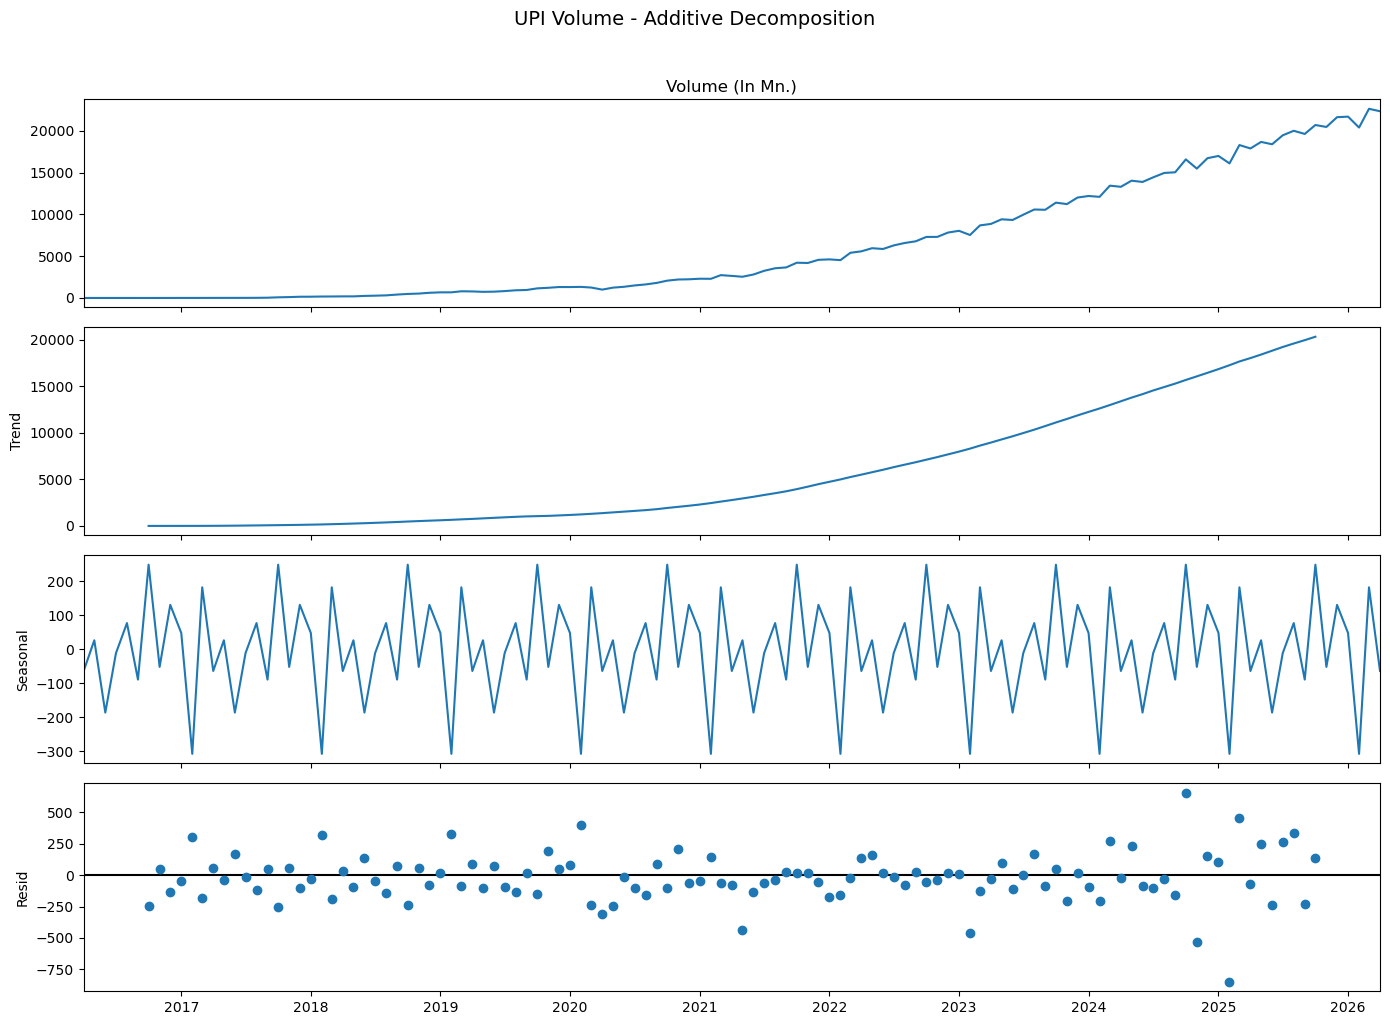

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_indexed = df_sorted.set_index("ds")["Volume (In Mn.)"]

decomp_add = seasonal_decompose(df_indexed, model="additive", period=12)
fig = decomp_add.plot()
fig.set_size_inches(14, 10)
fig.suptitle("UPI Volume - Additive Decomposition", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

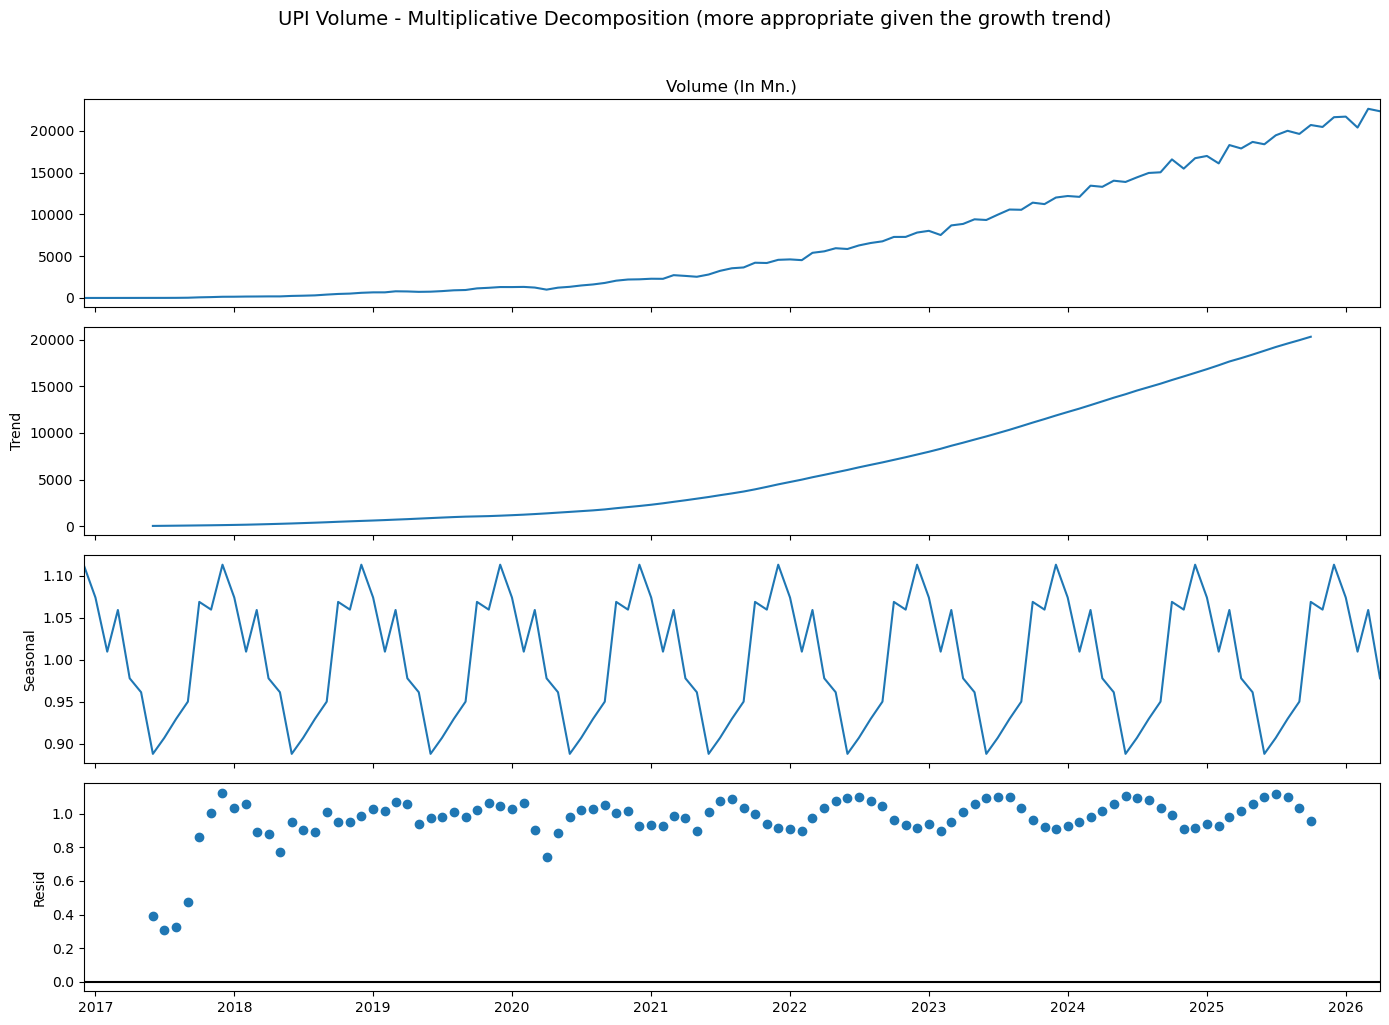

In [17]:
# Drop early-2016 rows where volume is near zero (distorts multiplicative decomposition)
df_indexed_mult = df_indexed[df_indexed > 1]

decomp_mult = seasonal_decompose(df_indexed_mult, model="multiplicative", period=12)
fig = decomp_mult.plot()
fig.set_size_inches(14, 10)
fig.suptitle("UPI Volume - Multiplicative Decomposition (more appropriate given the growth trend)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
#baseline model - seasonal naive

In [12]:
naive_forecast = df_sorted["Volume (In Mn.)"].shift(12)
naive_eval = pd.DataFrame({
    "ds": df_sorted["ds"],
    "actual": df_sorted["Volume (In Mn.)"],
    "naive_pred": naive_forecast,
}).dropna()

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

naive_mape = mean_absolute_percentage_error(naive_eval["actual"], naive_eval["naive_pred"]) * 100
naive_rmse = mean_squared_error(naive_eval["actual"], naive_eval["naive_pred"]) ** 0.5

print(f"Seasonal-naive baseline -> MAPE: {naive_mape:.2f}%, RMSE: {naive_rmse:.1f}")

Seasonal-naive baseline -> MAPE: 52.37%, RMSE: 2877.9


In [20]:
#prophet forecast

In [13]:
from prophet import Prophet

prophet_df = df_sorted[['ds', 'Volume (In Mn.)']].rename(columns={'Volume (In Mn.)': 'y'})
prophet_df.tail()

,ds,y
116,2025-12-01,21634.67
117,2026-01-01,21703.44
118,2026-02-01,20394.18
119,2026-03-01,22641.11
120,2026-04-01,22346.80


In [14]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # monthly data, no weekly pattern
    daily_seasonality=False,
    interval_width=0.95,
)
model.fit(prophet_df)
print("Model fitted")

10:13:37 - cmdstanpy - INFO - Chain [1] start processing
10:13:38 - cmdstanpy - INFO - Chain [1] done processing


Model fitted


In [15]:
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
121,2026-05-01,22975.367238,22556.551193,23423.107784
122,2026-06-01,23163.992475,22740.382619,23566.299808
123,2026-07-01,23709.128099,23248.045581,24098.718977
124,2026-08-01,24183.052137,23760.844284,24652.028884
125,2026-09-01,24405.839521,23967.750748,24830.388474
126,2026-10-01,25064.266297,24600.726987,25554.864253
127,2026-11-01,25192.787184,24717.807130,25695.221739
128,2026-12-01,25793.399025,25297.333926,26292.104113
129,2027-01-01,26060.369461,25542.126746,26615.618613
130,2027-02-01,26014.106331,25470.189645,26543.363482


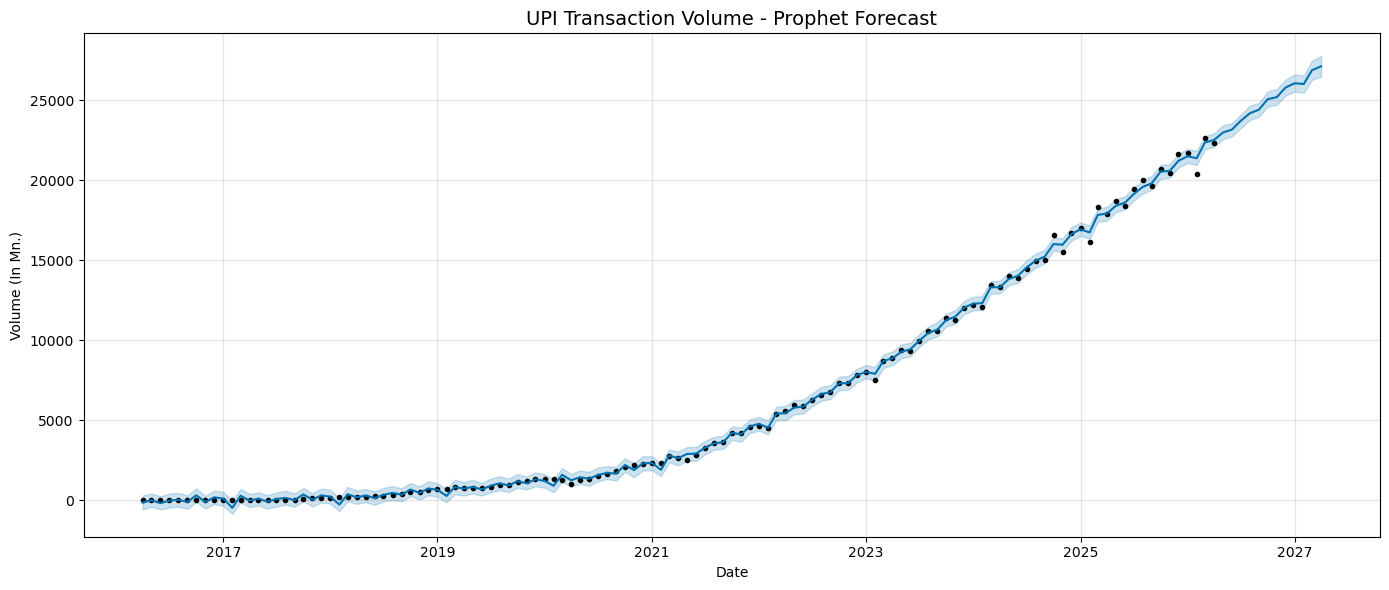

In [16]:
fig1 = model.plot(forecast, figsize=(14, 6))
plt.title("UPI Transaction Volume - Prophet Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Volume (In Mn.)")
plt.tight_layout()
plt.show()

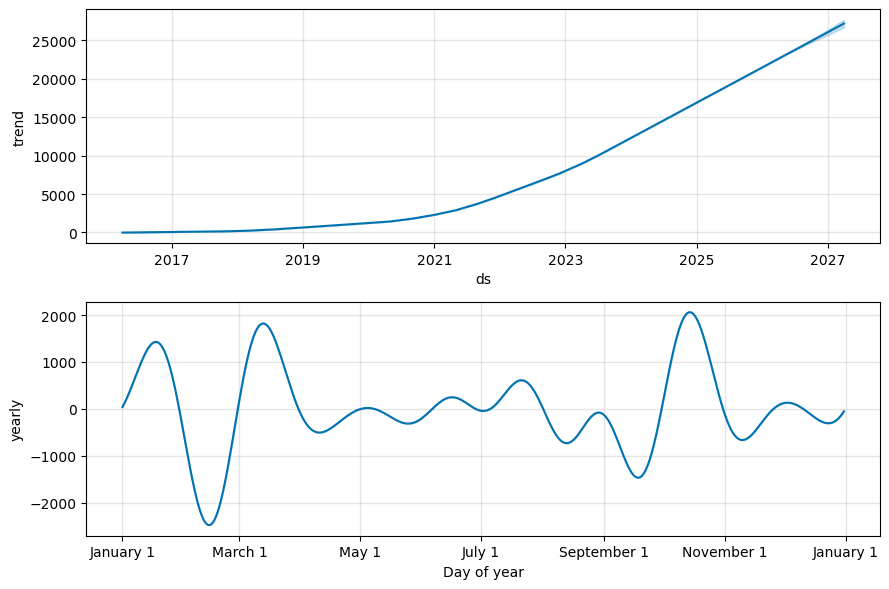

In [18]:
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [26]:
# change components

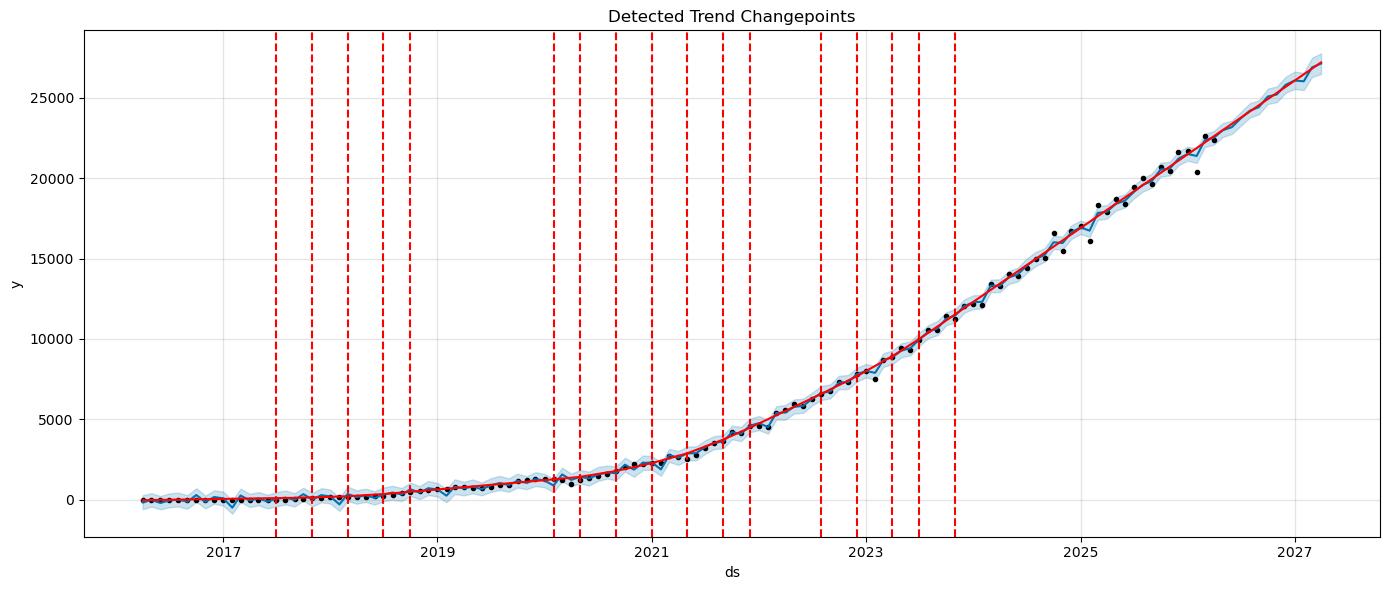

Significant changepoints detected:
['2017-07', '2017-11', '2018-03', '2018-07', '2018-10', '2020-02', '2020-05', '2020-09', '2021-01', '2021-05', '2021-09', '2021-12', '2022-08', '2022-12', '2023-04', '2023-07', '2023-11']


In [19]:
from prophet.plot import add_changepoints_to_plot

fig = model.plot(forecast, figsize=(14, 6))
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.title("Detected Trend Changepoints")
plt.tight_layout()
plt.show()

print("Significant changepoints detected:")
significant = model.changepoints[abs(model.params['delta'].mean(axis=0)) > 0.01]
print(significant.dt.strftime('%Y-%m').tolist())

In [ ]:
#backtest

10:14:50 - cmdstanpy - INFO - Chain [1] start processing
10:14:50 - cmdstanpy - INFO - Chain [1] done processing


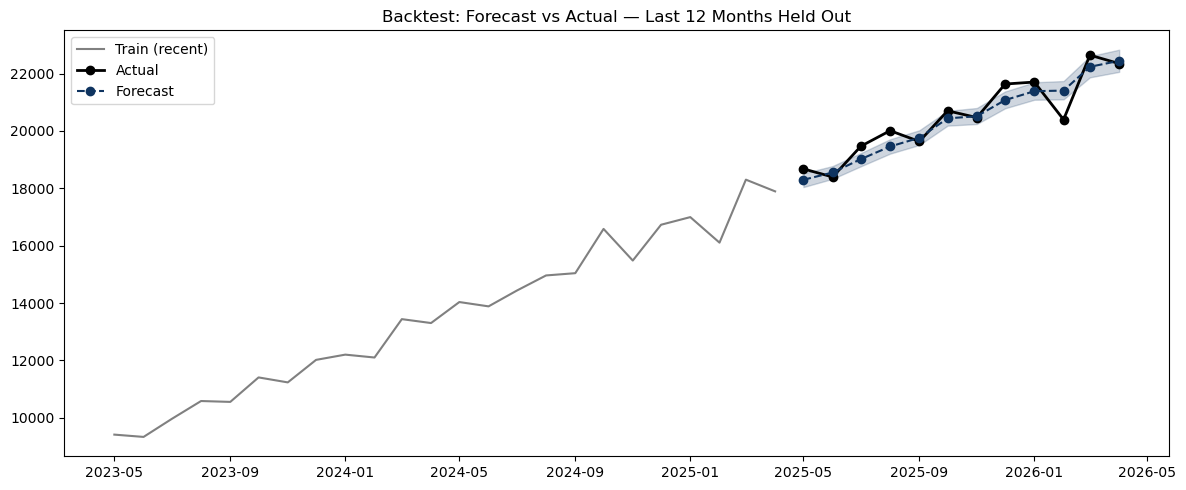

Backtest MAPE (last 12 months):        1.78%
Seasonal-naive baseline MAPE (same window): 22.71%
Seasonal-naive baseline MAPE (full history): 52.37%  (for reference only — different window, not directly comparable)


In [20]:
holdout_months = 12
train_df = prophet_df.iloc[:-holdout_months]
test_df = prophet_df.iloc[-holdout_months:]

backtest_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
backtest_model.fit(train_df)

future_bt = backtest_model.make_future_dataframe(periods=holdout_months, freq='MS')
forecast_bt = backtest_model.predict(future_bt)
backtest_pred = forecast_bt.tail(holdout_months)

plt.figure(figsize=(12, 5))
plt.plot(train_df["ds"].tail(24), train_df["y"].tail(24), label="Train (recent)", color="gray")
plt.plot(test_df["ds"], test_df["y"], label="Actual", color="black", linewidth=2, marker="o")
plt.plot(backtest_pred["ds"], backtest_pred["yhat"], label="Forecast", color="#0f3460", linestyle="--", marker="o")
plt.fill_between(backtest_pred["ds"], backtest_pred["yhat_lower"], backtest_pred["yhat_upper"], alpha=0.2, color="#0f3460")
plt.title(f"Backtest: Forecast vs Actual — Last {holdout_months} Months Held Out")
plt.legend()
plt.tight_layout()
plt.show()

backtest_mape = mean_absolute_percentage_error(test_df["y"].values, backtest_pred["yhat"].values) * 100

# Fair, same-window naive baseline: forecast for each held-out month = actual value from 12 months earlier
naive_holdout_pred = df_sorted["Volume (In Mn.)"].shift(12).iloc[-holdout_months:]
naive_holdout_mape = mean_absolute_percentage_error(test_df["y"].values, naive_holdout_pred.values) * 100

print(f"Backtest MAPE (last {holdout_months} months):        {backtest_mape:.2f}%")
print(f"Seasonal-naive baseline MAPE (same window): {naive_holdout_mape:.2f}%")
print(f"Seasonal-naive baseline MAPE (full history): {naive_mape:.2f}%  (for reference only — different window, not directly comparable)")

In [29]:
#cross validated evaluation

In [21]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model,
    initial='730 days',    # train on first 2 years minimum
    period='90 days',      # retrain every 3 months
    horizon='365 days',    # test 12 months ahead each time
)

metrics = performance_metrics(df_cv)
metrics[['horizon', 'rmse', 'mae', 'mape']].tail(10)

  0%|          | 0/29 [00:00<?, ?it/s]

10:15:08 - cmdstanpy - INFO - Chain [1] start processing
10:15:09 - cmdstanpy - INFO - Chain [1] done processing
10:15:09 - cmdstanpy - INFO - Chain [1] start processing
10:15:09 - cmdstanpy - INFO - Chain [1] done processing
10:15:10 - cmdstanpy - INFO - Chain [1] start processing
10:15:10 - cmdstanpy - INFO - Chain [1] done processing
10:15:10 - cmdstanpy - INFO - Chain [1] start processing
10:15:10 - cmdstanpy - INFO - Chain [1] done processing
10:15:11 - cmdstanpy - INFO - Chain [1] start processing
10:15:11 - cmdstanpy - INFO - Chain [1] done processing
10:15:11 - cmdstanpy - INFO - Chain [1] start processing
10:15:12 - cmdstanpy - INFO - Chain [1] done processing
10:15:12 - cmdstanpy - INFO - Chain [1] start processing
10:15:12 - cmdstanpy - INFO - Chain [1] done processing
10:15:13 - cmdstanpy - INFO - Chain [1] start processing
10:15:13 - cmdstanpy - INFO - Chain [1] done processing
10:15:13 - cmdstanpy - INFO - Chain [1] start processing
10:15:14 - cmdstanpy - INFO - Chain [1]

,horizon,rmse,mae,mape
217,354 days,1104.726731,967.104096,0.196087
218,355 days,1117.457618,977.106589,0.195112
219,356 days,1123.693214,982.389780,0.193532
220,358 days,1172.345208,1016.837981,0.211766
221,360 days,1128.669000,971.253736,0.221486
222,361 days,1129.799389,973.707730,0.211717
223,362 days,1125.935853,968.042314,0.214106
224,363 days,1110.787120,946.285470,0.207804
225,364 days,1083.050571,911.900988,0.214777
226,365 days,1079.828755,901.480369,0.201056


In [ ]:
#final output

In [31]:
next_12 = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12).copy()
next_12.columns = ['Month', 'Forecast (Mn)', 'Lower Bound', 'Upper Bound']
next_12['Month'] = next_12['Month'].dt.strftime('%b-%Y')
next_12 = next_12.round(2).reset_index(drop=True)

next_12.to_csv("upi_forecast_next_12_months.csv", index=False)
print(next_12.to_string(index=False))
print("\nSaved to upi_forecast_next_12_months.csv")

   Month  Forecast (Mn)  Lower Bound  Upper Bound
May-2026       22975.37     22591.31     23374.29
Jun-2026       23163.99     22733.08     23584.29
Jul-2026       23709.13     23284.66     24160.40
Aug-2026       24183.05     23761.46     24614.09
Sep-2026       24405.84     23949.33     24866.19
Oct-2026       25064.27     24629.70     25503.05
Nov-2026       25192.79     24706.76     25638.70
Dec-2026       25793.40     25326.61     26265.06
Jan-2027       26060.37     25575.18     26602.99
Feb-2027       26014.11     25509.34     26583.10
Mar-2027       26877.39     26291.46     27433.79
Apr-2027       27118.72     26532.44     27718.14

Saved to upi_forecast_next_12_months.csv
